In [24]:
# Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import altair as alt
import matplotlib.pyplot as plt

In [25]:
# Load People.csv, FieldingPost.csv, PitchingPost.csv, BattingPost.csv, Schools.csv, Salaries.csv, Appearances.csv, HallOfFame.csvf
DATA_PATH = "baseball/core/"
ppl  = pd.read_csv(DATA_PATH + "People.csv")
fld  = pd.read_csv(DATA_PATH + "FieldingPost.csv")
pch  = pd.read_csv(DATA_PATH + "PitchingPost.csv")
bat  = pd.read_csv(DATA_PATH + "BattingPost.csv")
scl  = pd.read_csv(DATA_PATH + "Schools.csv")
sal  = pd.read_csv(DATA_PATH + "Salaries.csv")
hof  = pd.read_csv(DATA_PATH + "HallOfFame.csv")
app  = pd.read_csv(DATA_PATH + "Appearances.csv")

In [26]:
# Check the datasets
print("People:", ppl.shape)
print("Salaries:", sal.shape)
print("Hall of Fame:", hof.shape)
print("Appearances:", app.shape)

People: (19370, 24)
Salaries: (26428, 5)
Hall of Fame: (4191, 9)
Appearances: (104256, 21)


In [27]:
print("People columns")
print(ppl.columns.tolist())

print("\nSalary columns:")
print(sal.columns.tolist())

print("\nHall of Fame columns:")
print(hof.columns.tolist())

print("\nAppearance columns:")
print(app.columns.tolist())

People columns
['playerID', 'birthYear', 'birthMonth', 'birthDay', 'birthCountry', 'birthState', 'birthCity', 'deathYear', 'deathMonth', 'deathDay', 'deathCountry', 'deathState', 'deathCity', 'nameFirst', 'nameLast', 'nameGiven', 'weight', 'height', 'bats', 'throws', 'debut', 'finalGame', 'retroID', 'bbrefID']

Salary columns:
['yearID', 'teamID', 'lgID', 'playerID', 'salary']

Hall of Fame columns:
['playerID', 'yearid', 'votedBy', 'ballots', 'needed', 'votes', 'inducted', 'category', 'needed_note']

Appearance columns:
['yearID', 'teamID', 'lgID', 'playerID', 'G_all', 'GS', 'G_batting', 'G_defense', 'G_p', 'G_c', 'G_1b', 'G_2b', 'G_3b', 'G_ss', 'G_lf', 'G_cf', 'G_rf', 'G_of', 'G_dh', 'G_ph', 'G_pr']


In [28]:
# Analysis of Hall of Fame vs Salary
# Particularly, is Hall of Fame membership associated 
# with higher career salary among MLB players? Does the
# relationship remain when noting total seasons played?

# Identifying Hall of Fame players
hofPlayers = hof[hof["inducted"] == "Y"][["playerID"]].drop_duplicates()
print("Number of Hall of Fame players:", len(hofPlayers))
display(hofPlayers.head())

Number of Hall of Fame players: 323


,playerID
0,cobbty01
1,ruthba01
2,wagneho01
3,mathech01
4,johnswa01


In [29]:
# Lets check the salaries of the Hall of Famers

salaryHOF = sal.merge(
    hofPlayers.assign(hallOfFame=True),
    on="playerID",
    how="left"
)
salaryHOF["hallOfFame"] = salaryHOF["hallOfFame"].fillna(False)
display(salaryHOF.head())

,yearID,teamID,lgID,playerID,salary,hallOfFame
0,1985,ATL,NL,barkele01,870000,False
1,1985,ATL,NL,bedrost01,550000,False
2,1985,ATL,NL,benedbr01,545000,False
3,1985,ATL,NL,campri01,633333,False
4,1985,ATL,NL,ceronri01,625000,False


In [30]:
# Individual seasons may not be the smartest decision
# so let's calculate the total salary recorded

careerSalary = (
    salaryHOF
    .groupby(["playerID", "hallOfFame"], as_index=False)
    .agg(
        careerSalary=("salary", "sum"),
        averageSalary=("salary", "mean"),
        seasonsPaid=("yearID", "nunique")
    )
)

print("Rows to compare:", len(careerSalary))
careerSalary = careerSalary.merge(
    ppl[["playerID", "nameFirst", "nameLast"]],
    on="playerID",
    how="left"
)
careerSalary["name"] = (
    careerSalary["nameFirst"] + " " + careerSalary["nameLast"]
)
display(careerSalary.head())

Rows to compare: 5149


,playerID,hallOfFame,careerSalary,averageSalary,seasonsPaid,nameFirst,nameLast,name
0,aardsda01,False,9259750,1.322821e+06,7,David,Aardsma,David Aardsma
1,aasedo01,False,2300000,5.750000e+05,4,Don,Aase,Don Aase
2,abadan01,False,327000,3.270000e+05,1,Andy,Abad,Andy Abad
3,abadfe01,False,3766400,7.532800e+05,5,Fernando,Abad,Fernando Abad
4,abbotje01,False,985000,2.462500e+05,4,Jeff,Abbott,Jeff Abbott


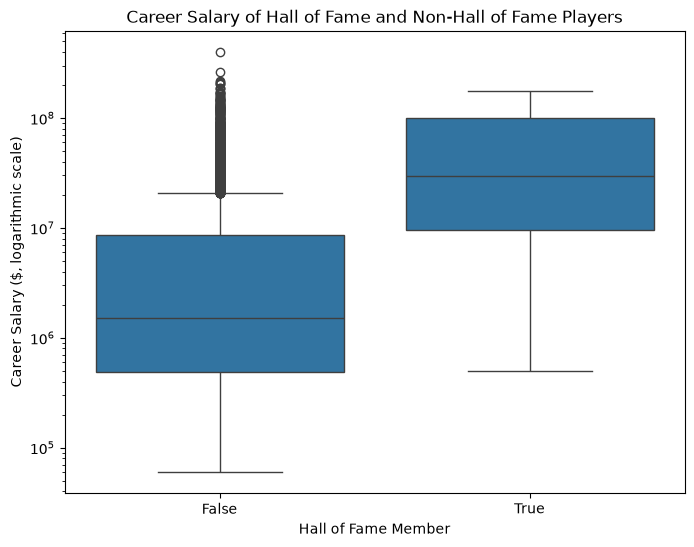

In [31]:
# Lets compare the groups
careerSalary.groupby("hallOfFame")[
    ["careerSalary", "averageSalary", "seasonsPaid"]
    ].median()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=careerSalary,
    x="hallOfFame",
    y="careerSalary"
)

plt.yscale("log")
plt.title("Career Salary of Hall of Fame and Non-Hall of Fame Players")
plt.xlabel("Hall of Fame Member")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()

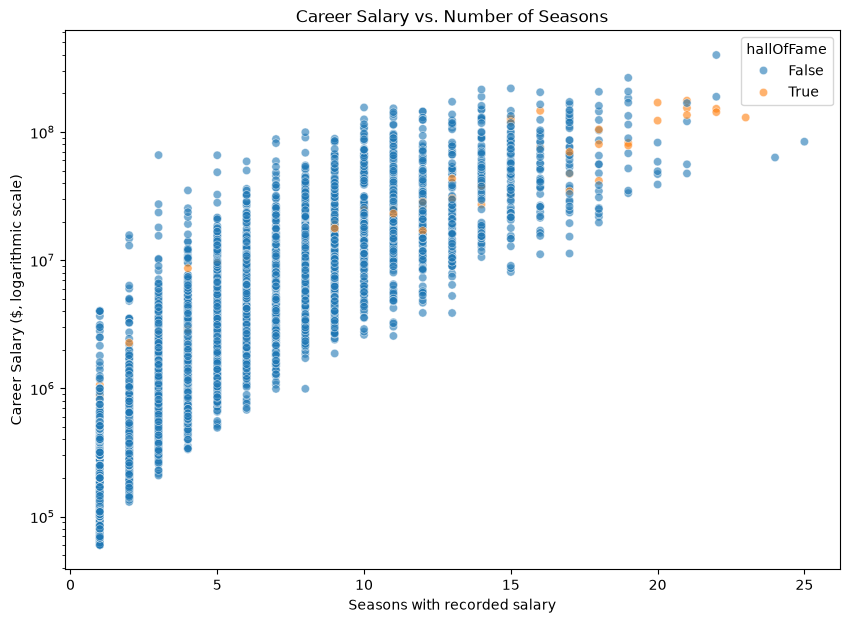

In [33]:
# The above graph shouldn't be all that surprising, so
# let's see if it's because they play longer or they
# actually command higher salaries

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=careerSalary,
    x="seasonsPaid",
    y="careerSalary",
    hue="hallOfFame",
    alpha=0.6
)
plt.yscale("log")
plt.title("Career Salary vs. Number of Seasons")
plt.xlabel("Seasons with recorded salary")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()